In [ ]:
!pip install -q transformers datasets accelerate evaluate librosa soundfile scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import torch
import librosa

from datasets import load_dataset, Dataset
from transformers import (
    ASTFeatureExtractor,
    ASTForAudioClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

In [ ]:
ds_train = load_dataset("szzs1693/coswara-data", "audio", split="train")
ds_val   = load_dataset("szzs1693/coswara-data", "audio", split="val")
ds_test  = load_dataset("szzs1693/coswara-data", "audio", split="test")

print(len(ds_train), len(ds_val), len(ds_test))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

17298 3708 3708


In [ ]:
types = set([x["audio_type"] for x in ds_train])
print(types)

{'cough-shallow', 'cough-heavy', 'vowel-a', 'counting-normal', 'counting-fast', 'vowel-e', 'vowel-o', 'breathing-shallow', 'breathing-deep'}


In [ ]:
COUGH_TYPES = ["cough-heavy", "cough-shallow"]

def filter_cough(ds):
    return ds.filter(lambda x: x["audio_type"] in COUGH_TYPES)

ds_train = filter_cough(ds_train)
ds_val   = filter_cough(ds_val)
ds_test  = filter_cough(ds_test)

print(len(ds_train), len(ds_val), len(ds_test))

Filter:   0%|          | 0/17298 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3708 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3708 [00:00<?, ? examples/s]

3844 824 824


In [ ]:
def detect_clipping(y):
    return float(np.mean(np.abs(y) >= 0.99))

def detect_rms(y):
    return float(np.sqrt(np.mean(y**2)))

def assign_quality_label(y):

    rms = detect_rms(y)
    clip = detect_clipping(y)

    if clip > 0.02:
        return "clipped"

    if rms < 0.01:
        return "too_low_volume"

    if rms < 0.03:
        return "noisy"

    return "clean"

In [ ]:
def build_metadata(ds):
    records = []
    skipped_none = 0
    skipped_empty = 0
    skipped_error = 0

    for i, sample in enumerate(ds):
        try:
            audio_obj = sample["audio"]

            if audio_obj is None:
                skipped_none += 1
                continue

            decoded = audio_obj.get_all_samples()

            if hasattr(decoded, "data"):
                y = decoded.data
            else:
                y = decoded

            if hasattr(y, "cpu"):
                y = y.cpu().numpy()

            y = np.asarray(y, dtype=np.float32)

            if y.ndim == 2:
                y = y.mean(axis=0)

            if y is None or len(y) == 0:
                skipped_empty += 1
                continue

            label = assign_quality_label(y)

            records.append({
                "index": i,
                "label_name": label
            })

        except Exception:
            skipped_error += 1
            continue

    df = pd.DataFrame(records)

    print("usable:", len(df))
    print("skipped_none:", skipped_none)
    print("skipped_empty:", skipped_empty)
    print("skipped_error:", skipped_error)

    return df

train_df = build_metadata(ds_train)
val_df   = build_metadata(ds_val)
test_df  = build_metadata(ds_test)

usable: 3783
skipped_none: 61
skipped_empty: 0
skipped_error: 0
usable: 812
skipped_none: 12
skipped_empty: 0
skipped_error: 0
usable: 813
skipped_none: 11
skipped_empty: 0
skipped_error: 0


In [ ]:
print("Train distribution:")
print(train_df["label_name"].value_counts())

print("\nVal distribution:")
print(val_df["label_name"].value_counts())

print("\nTest distribution:")
print(test_df["label_name"].value_counts())

Train distribution:
label_name
clean             3246
noisy              322
too_low_volume     215
Name: count, dtype: int64

Val distribution:
label_name
clean             684
noisy              75
too_low_volume     53
Name: count, dtype: int64

Test distribution:
label_name
clean             685
noisy              68
too_low_volume     60
Name: count, dtype: int64


In [ ]:
CLASS_NAMES = ["clean", "noisy", "too_low_volume"]

label2id = {c: i for i, c in enumerate(CLASS_NAMES)}
id2label = {i: c for c, i in label2id.items()}

train_df = train_df[train_df["label_name"].isin(CLASS_NAMES)].copy()
val_df   = val_df[val_df["label_name"].isin(CLASS_NAMES)].copy()
test_df  = test_df[test_df["label_name"].isin(CLASS_NAMES)].copy()

train_df["label"] = train_df["label_name"].map(label2id)
val_df["label"]   = val_df["label_name"].map(label2id)
test_df["label"]  = test_df["label_name"].map(label2id)

print(train_df.head())

   index label_name  label
0      0      clean      0
1      1      clean      0
2      2      clean      0
3      3      clean      0
4      4      clean      0


In [ ]:
from datasets import Dataset

train_hf = Dataset.from_pandas(train_df[["index", "label"]], preserve_index=False)
val_hf   = Dataset.from_pandas(val_df[["index", "label"]], preserve_index=False)
test_hf  = Dataset.from_pandas(test_df[["index", "label"]], preserve_index=False)

print(train_hf)
print(val_hf)
print(test_hf)

Dataset({
    features: ['index', 'label'],
    num_rows: 3783
})
Dataset({
    features: ['index', 'label'],
    num_rows: 812
})
Dataset({
    features: ['index', 'label'],
    num_rows: 813
})


In [ ]:
from transformers import ASTFeatureExtractor, ASTForAudioClassification

CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = ASTFeatureExtractor.from_pretrained(CHECKPOINT)

TARGET_SR = feature_extractor.sampling_rate
MAX_SECONDS = 5
MAX_LENGTH = TARGET_SR * MAX_SECONDS

print("Target SR:", TARGET_SR)
print("Max length:", MAX_LENGTH)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Target SR: 16000
Max length: 80000


In [ ]:
def standardize_audio_from_sample(sample, target_sr=TARGET_SR, max_length=MAX_LENGTH):
    audio_obj = sample["audio"]
    decoded = audio_obj.get_all_samples()

    if hasattr(decoded, "data"):
        y = decoded.data
    else:
        y = decoded

    if hasattr(y, "cpu"):
        y = y.cpu().numpy()

    y = np.asarray(y, dtype=np.float32)

    if y.ndim == 2:
        y = y.mean(axis=0)

    sr = getattr(decoded, "sample_rate", 16000)

    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

    y, _ = librosa.effects.trim(y, top_db=20)

    if len(y) == 0:
        y = np.zeros(max_length, dtype=np.float32)

    if len(y) < max_length:
        y = np.pad(y, (0, max_length - len(y)))
    else:
        y = y[:max_length]

    return y.astype(np.float32)

In [ ]:
def preprocess_train(example):
    sample = ds_train[int(example["index"])]
    y = standardize_audio_from_sample(sample)

    features = feature_extractor(
        y,
        sampling_rate=TARGET_SR,
        max_length=MAX_LENGTH,
        truncation=True
    )

    return {
        "input_values": features["input_values"][0],
        "label": example["label"]
    }

def preprocess_val(example):
    sample = ds_val[int(example["index"])]
    y = standardize_audio_from_sample(sample)

    features = feature_extractor(
        y,
        sampling_rate=TARGET_SR,
        max_length=MAX_LENGTH,
        truncation=True
    )

    return {
        "input_values": features["input_values"][0],
        "label": example["label"]
    }

def preprocess_test(example):
    sample = ds_test[int(example["index"])]
    y = standardize_audio_from_sample(sample)

    features = feature_extractor(
        y,
        sampling_rate=TARGET_SR,
        max_length=MAX_LENGTH,
        truncation=True
    )

    return {
        "input_values": features["input_values"][0],
        "label": example["label"]
    }

In [ ]:
train_hf = train_hf.map(preprocess_train, remove_columns=["index"])
val_hf   = val_hf.map(preprocess_val, remove_columns=["index"])
test_hf  = test_hf.map(preprocess_test, remove_columns=["index"])

train_hf.set_format(type="torch", columns=["input_values", "label"])
val_hf.set_format(type="torch", columns=["input_values", "label"])
test_hf.set_format(type="torch", columns=["input_values", "label"])

print(train_hf[0].keys())

Map:   0%|          | 0/3783 [00:00<?, ? examples/s]

Map:   0%|          | 0/812 [00:00<?, ? examples/s]

Map:   0%|          | 0/813 [00:00<?, ? examples/s]

dict_keys(['label', 'input_values'])


In [ ]:
model = ASTForAudioClassification.from_pretrained(
    CHECKPOINT,
    num_labels=len(CLASS_NAMES),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Device:", device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([3, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([3])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Device: cuda


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [ ]:
from transformers import TrainingArguments, Trainer

OUTPUT_DIR = "/content/ast_coswara_quality_3class"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available()
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    processing_class=feature_extractor,
    compute_metrics=compute_metrics,
)

In [ ]:
train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
feature_extractor.save_pretrained(OUTPUT_DIR)

print("Training complete.")

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.197470,0.106416,0.953202,0.929268,0.833758,0.873782
2,0.102460,0.098172,0.966749,0.917945,0.916149,0.916825
3,0.007129,0.143455,0.967980,0.940565,0.896583,0.915629
4,0.000103,0.218667,0.960591,0.928867,0.871761,0.892232
5,0.000032,0.196433,0.960591,0.915426,0.872029,0.889918
6,0.000052,0.173502,0.969212,0.924037,0.908942,0.915125


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.


In [ ]:
test_metrics = trainer.evaluate(eval_dataset=test_hf)
print(test_metrics)

{'eval_loss': 0.09053486585617065, 'eval_accuracy': 0.9704797047970479, 'eval_precision_macro': 0.9054118004214436, 'eval_recall_macro': 0.9238919898859788, 'eval_f1_macro': 0.9144007507643872, 'eval_runtime': 57.1649, 'eval_samples_per_second': 14.222, 'eval_steps_per_second': 1.784, 'epoch': 6.0}


In [ ]:
pred_output = trainer.predict(test_hf)

y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

                precision    recall  f1-score   support

         clean     0.9926    0.9854    0.9890       685
         noisy     0.8056    0.8529    0.8286        68
too_low_volume     0.9180    0.9333    0.9256        60

      accuracy                         0.9705       813
     macro avg     0.9054    0.9239    0.9144       813
  weighted avg     0.9715    0.9705    0.9709       813



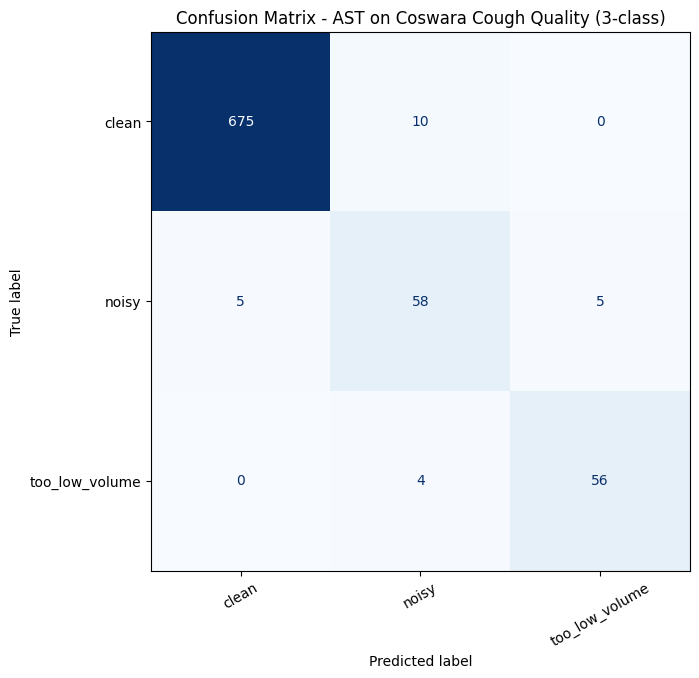

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=30, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - AST on Coswara Cough Quality (3-class)")
plt.show()

In [ ]:
import time

model.eval()

sample = test_hf[0]["input_values"].unsqueeze(0).to(device)

for _ in range(10):
    with torch.no_grad():
        _ = model(input_values=sample)

if device == "cuda":
    torch.cuda.synchronize()

times = []
for _ in range(100):
    start = time.perf_counter()
    with torch.no_grad():
        _ = model(input_values=sample)
    if device == "cuda":
        torch.cuda.synchronize()
    end = time.perf_counter()
    times.append((end - start) * 1000)

print(f"Average latency: {np.mean(times):.2f} ms")
print(f"Std latency: {np.std(times):.2f} ms")
print(f"Min latency: {np.min(times):.2f} ms")
print(f"Max latency: {np.max(times):.2f} ms")

Average latency: 23.68 ms
Std latency: 4.08 ms
Min latency: 19.30 ms
Max latency: 53.69 ms
